In [1]:
import biolqm
import ginsim
from colomoto.minibn import BooleanNetwork
from colomoto_jupyter import tabulate
import pandas as pd # for displaying list of fixpoints

This notebook has been executed using the docker image `colomoto/colomoto-docker:2019-12-19`

## Create Model

In [2]:
F = BooleanNetwork()

In [6]:
lr, ra, ai, rag, li = F.vars("lr", "ra", "ai", "rag", "li")

In [60]:
F[lr] = ~rag|(lr&~ai)
F[ra] = ai&lr
F[ai] = li|(ai&~lr)
F[rag] = ra
F[li] = rag

In [61]:
F

ai <- li|(ai&!lr)
li <- rag
lr <- !rag|(lr&!ai)
ra <- ai&lr
rag <- ra

In [62]:
lqm = F.to_biolqm()

In [63]:
lrg = biolqm.to_ginsim(lqm)

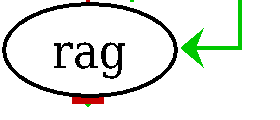

In [73]:
ginsim.show(lrg)

## Attractors & Fixpoints

#### Attractors

In [14]:
m = ginsim.to_pint(lrg)

In [15]:
attractors = m.reachable_attractors()

In [16]:
attractors

[{'type': 'fixpoint',
  'size': 1,
  'sample': {'ai': 0, 'li': 0, 'lr': 0, 'ra': 0, 'rag': 0}}]

#### Fixpoints

In [72]:
fps = biolqm.fixpoints(lqm)
print(len(fps), "fixpoints")
pd.DataFrame(fps)

1 fixpoints


,ai,li,lr,ra,rag
0,0,0,1,0,0


## TEST

In [79]:
#state 5
trace2 = biolqm.trace(lqm, "-u synchronous -i 10100 -m 50")
pd.DataFrame( [s for s in trace2] )

,ai,li,lr,ra,rag
0,1,0,1,0,0
1,0,0,1,1,0
2,0,0,1,0,1
3,0,1,1,0,0
4,1,0,1,0,0


In [76]:
#state 13
trace1 = biolqm.trace(lqm, "-u synchronous -i 10110 -m 50")
pd.DataFrame( [s for s in trace1] )

,ai,li,lr,ra,rag
0,1,0,1,1,0
1,0,0,1,1,1
2,0,1,1,0,1
3,1,1,1,0,0
4,1,0,1,1,0


In [78]:
#state 21
trace3 = biolqm.trace(lqm, "-u synchronous -i 10101 -m 50")
pd.DataFrame( [s for s in trace3] )

,ai,li,lr,ra,rag
0,1,0,1,0,1
1,0,1,0,1,0
2,1,0,1,0,1


In [80]:
#state 0
trace4 = biolqm.trace(lqm, "-u synchronous -i 00000 -m 50")
pd.DataFrame( [s for s in trace4] )

,ai,li,lr,ra,rag
0,0,0,0,0,0
1,0,0,1,0,0


In [85]:
#state 4
trace5 = biolqm.trace(lqm, "-u synchronous -i 00100 -m 50")
pd.DataFrame( [s for s in trace5] )

,ai,li,lr,ra,rag
0,0,0,1,0,0
